In [1]:
#solve the low thrust optimization problem as an qcqp 

#this is a onestep problem with the cost and constraints written in qcqp format

#we want to be able to match this solution with the polynomial optimization methods
using Pkg
Pkg.activate(".")

  Activating project at `~/Research/polynomial_opt`


In [2]:
using Test 
using LinearAlgebra
using SparseArrays
using Plots
using ForwardDiff
import lazy_nlp_qd 

In [3]:
#sizes of all the states 
#make sure to start the state vector with a 1 

#position at timestep k
nq = 3

#velocity at timestep k 
nv = 3

#position at timestep k+1
nq1 = 3

#velocity at timestep k+1 
nv1 = 3

#acceleration at timestep k 
na = 3

#slack for norm q 
nr = 1

#slack for norm q1
nr1 = 1

#slack for r^2 
ns = 1

#slack for r^3 
nw = 1

#control variable 
nu = 3

3

In [4]:
#gravitational parameter for the Earth 
μ = 3.986004418e5 #km3/s2

398600.4418

In [5]:
#iss initial conditions
r0 = [6791.0; 0; 0] #km
v0 = [0; cosd(51.5)*7.66; sind(51.5)*7.66] #km/s
x_initial_0 = [r0; v0]

6-element Vector{Float64}:
 6791.0
    0.0
    0.0
    0.0
    4.768462116644166
    5.994778481489491

In [6]:
#finding the period
r_initial = norm(r0)

#for 1 rev
iss_period = 2*pi*sqrt(r_initial^3/μ)

5569.440597283014

In [7]:
#working for 1 rev ...
#revs = 1

#around 8 min solve time... (working)
#revs = 10

#revs for polynomial opt example (working) 4 second solve time 
revs = 1

#period 
period = revs*iss_period 

5569.440597283014

In [8]:
#working with 10 rev horizon 
#knot_pts = 30

#course discretization that we try out in the polynomial opt example
#working with 5 rev horizon
knot_pts = 2

#number of knot points  
N= 2

2

In [9]:
#define a timestep
#in seconds 
h = period/(41-1) 

139.23601493207534

In [10]:
function two_body_dynamics(x)

    q = x[1:3]
    v = x[4:6]

    a = zeros(eltype(x), size(x))

    r = norm(q)
    
    a[1:3] = v

    a[4:6] = (-μ/r^3)*q

    return a

end

two_body_dynamics (generic function with 1 method)

In [11]:
#semi implicit euler 
function symplectic_euler(x)

    #the q and the v are already scaled 
    q = x[1:3]
    v = x[4:6]

    #next timestep
    xnext = zeros(6)

    #ak = two_body_dynamics(x)[4:6]
    ak = (-μ/(norm(q)^3))*q
    #ak = (-μ_scaled/(norm(q)^3))*q


    #explicit euler on the velocities
    #vk1
    xnext[4:6] = v + h*ak

    #implicit euler on the positions
    #qk1
    xnext[1:3] = q + h*xnext[4:6]

    return xnext 

end

symplectic_euler (generic function with 1 method)

In [12]:
#integrate the orbit with symplectic euler to see if it closes

xtraj = zeros(6, N)

xtraj[:,1] = x_initial_0


6-element Vector{Float64}:
 6791.0
    0.0
    0.0
    0.0
    4.768462116644166
    5.994778481489491

In [13]:
#integrate using symplectic Euler to generate an initial guess
for i=1:N-1

    xtraj[:,i+1] = symplectic_euler(xtraj[:,i])

end


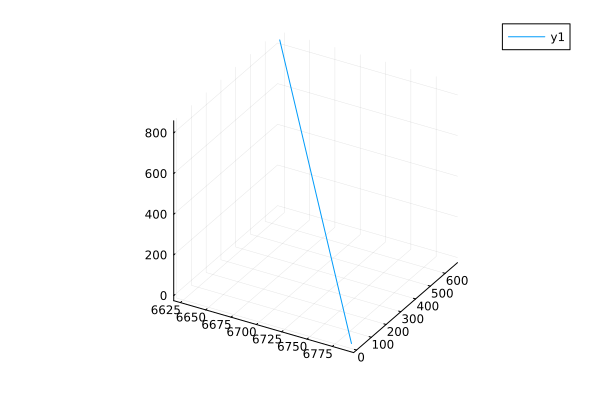

In [14]:
plot(xtraj[1,:], xtraj[2,:], xtraj[3,:])

In [15]:
#going to scale position by semi major axis length 
position_scale = r_initial 

#scaled to make the period 1 
#time_scale = iss_period 
#works with 1
#thrust_limit_kN = 0.000432

#this works with 29% sub opt gap  (block structure)
#0.6% opt gap with MD structure 
#this is working...
#thrust_limit_kN = 0.00002

#2 Newtons 
#thrust_limit_kN = 0.002

#2 milliNewton
#thrust_limit_kN = 0.000002

thrust_limit_kN = 20e-9

#currently in the testing code
#this works 
#thrust_limit_kN = 2e-5

#scale to make the minimum control 1
#time_scale = sqrt(position_scale/thrust_limit_kN)

#scaled to make the period 1
time_scale = period*5

velocity_scale = position_scale/time_scale

acceleration_scale = position_scale/time_scale^2

μ_scaled = μ/(position_scale^3/time_scale^2)

h_scaled = h/time_scale

u_max_bound = thrust_limit_kN/acceleration_scale 

0.002283807139350918

In [16]:
time_scale 

27847.202986415068

In [17]:
q_k = [1,2,3]

v_k = [4,5,6]

q_k1 = [1,2,3]

v_k1 = [4,5,6]

a_k = [1,2,3]

r_k = 10

r_k1 = 12

s_k = 13

w_k = 19

u_k = [2,3,4]


#create x as a vector of vectors/scalars
#indices work for this 
#x = [vector_1, vector_2, vector_3, scalar]

#check the indices code for this  
#x = [vector_1, vector_2, vector_3, vector_4, scalar]

x = [q_k, v_k, q_k1, v_k1, a_k, r_k, r_k1, s_k, w_k, u_k]


N_size = length(x)

#these are the sizes of each element
sizes = zeros(Int64, N_size)

for i=1:N_size

    sizes[i] = Int(length(x[i]))

end
#indices
#try to generate these automatically 
# v1_index = (2:4, 1)

# v2_index = (5:7, 1)

# v3_index = (8:10, 1)

# scalar_index = (11, 1)

# scalar_squared_index = (11,11)

In [18]:
flat_x = [1.0; Float64.(vcat(x...))] 

23-element Vector{Float64}:
  1.0
  1.0
  2.0
  3.0
  4.0
  5.0
  6.0
  1.0
  2.0
  3.0
  ⋮
  2.0
  3.0
 10.0
 12.0
 13.0
 19.0
  2.0
  3.0
  4.0

In [19]:
M = flat_x*flat_x' 

23×23 Matrix{Float64}:
  1.0   1.0   2.0   3.0   4.0   5.0    6.0  …   13.0   19.0   2.0   3.0   4.0
  1.0   1.0   2.0   3.0   4.0   5.0    6.0      13.0   19.0   2.0   3.0   4.0
  2.0   2.0   4.0   6.0   8.0  10.0   12.0      26.0   38.0   4.0   6.0   8.0
  3.0   3.0   6.0   9.0  12.0  15.0   18.0      39.0   57.0   6.0   9.0  12.0
  4.0   4.0   8.0  12.0  16.0  20.0   24.0      52.0   76.0   8.0  12.0  16.0
  5.0   5.0  10.0  15.0  20.0  25.0   30.0  …   65.0   95.0  10.0  15.0  20.0
  6.0   6.0  12.0  18.0  24.0  30.0   36.0      78.0  114.0  12.0  18.0  24.0
  1.0   1.0   2.0   3.0   4.0   5.0    6.0      13.0   19.0   2.0   3.0   4.0
  2.0   2.0   4.0   6.0   8.0  10.0   12.0      26.0   38.0   4.0   6.0   8.0
  3.0   3.0   6.0   9.0  12.0  15.0   18.0      39.0   57.0   6.0   9.0  12.0
  ⋮                             ⋮           ⋱                 ⋮          
  2.0   2.0   4.0   6.0   8.0  10.0   12.0      26.0   38.0   4.0   6.0   8.0
  3.0   3.0   6.0   9.0  12.0  15.0   18.0  …

In [20]:
sizes 

10-element Vector{Int64}:
 3
 3
 3
 3
 3
 1
 1
 1
 1
 3

In [21]:
#the first element can either be an Int64 or a range. same with the second element 
vectors = [Vector{Tuple{Union{Int64, UnitRange{Int64}}, Union{Int64, UnitRange{Int64}}}}() for _ in 1:N_size]

10-element Vector{Vector{Tuple{Union{UnitRange{Int64}, Int64}, Union{UnitRange{Int64}, Int64}}}}:
 []
 []
 []
 []
 []
 []
 []
 []
 []
 []

In [22]:
#there will be N+1 indices for each element in our state 

In [23]:
#this will only be for first order for now...

function generate_indices(x)

    #number of items in x 
    N = length(x)

    flat_x = [1.0; Float64.(vcat(x...))]

    indices = [Vector{Tuple{Union{Int64, UnitRange{Int64}}, Union{Int64, UnitRange{Int64}}}}() for _ in 1:N_size]
    #each element will have N+1 indices associated to it
    #the first is the index for the element itself
    # the second is the index for the element outer product with itself
    # the rest are the elements outer product with the other elements 
    
    #add the first index 
    push!(indices[1], (2:1+length(x[1]), 1:1))

    #initial index push 
    for i=2:N_size 

       push!(indices[i], (indices[i-1][1][1][end] .+ 1: indices[i-1][1][1][end] + length(x[i]), 1:1))

    end 

    for i=1:N_size
    
        for k=1:N_size

            push!(indices[i], (indices[i][k][1], indices[i][k][2][end] .+ 1: indices[i][k][2][end] + length(x[k])))

        end

    end

    return indices

end

generate_indices (generic function with 1 method)

In [24]:
#each set of indices is the vector itself, and then the vector outer product with itself and the other vectors are well
indices = generate_indices(x)

10-element Vector{Vector{Tuple{Union{UnitRange{Int64}, Int64}, Union{UnitRange{Int64}, Int64}}}}:
 [(2:4, 1:1), (2:4, 2:4), (2:4, 5:7), (2:4, 8:10), (2:4, 11:13), (2:4, 14:16), (2:4, 17:17), (2:4, 18:18), (2:4, 19:19), (2:4, 20:20), (2:4, 21:23)]
 [(5:7, 1:1), (5:7, 2:4), (5:7, 5:7), (5:7, 8:10), (5:7, 11:13), (5:7, 14:16), (5:7, 17:17), (5:7, 18:18), (5:7, 19:19), (5:7, 20:20), (5:7, 21:23)]
 [(8:10, 1:1), (8:10, 2:4), (8:10, 5:7), (8:10, 8:10), (8:10, 11:13), (8:10, 14:16), (8:10, 17:17), (8:10, 18:18), (8:10, 19:19), (8:10, 20:20), (8:10, 21:23)]
 [(11:13, 1:1), (11:13, 2:4), (11:13, 5:7), (11:13, 8:10), (11:13, 11:13), (11:13, 14:16), (11:13, 17:17), (11:13, 18:18), (11:13, 19:19), (11:13, 20:20), (11:13, 21:23)]
 [(14:16, 1:1), (14:16, 2:4), (14:16, 5:7), (14:16, 8:10), (14:16, 11:13), (14:16, 14:16), (14:16, 17:17), (14:16, 18:18), (14:16, 19:19), (14:16, 20:20), (14:16, 21:23)]
 [(17:17, 1:1), (17:17, 2:4), (17:17, 5:7), (17:17, 8:10), (17:17, 11:13), (17:17, 14:16), (17:17, 17:

In [25]:
#come up with the A matrices to construct the quadratic constraints of the form x'Ax. Here we are finding the A matrix

#this is the A matrix for the quadratic cost on r_k1

A_cost =  zeros(size(M))
A_cost[indices[7][1]...] = [1] 

#checked

1-element Vector{Int64}:
 1

In [73]:
A_cost 

23×23 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                        ⋮              ⋱                      ⋮         
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  

In [77]:
all_vals_eigen = eigen(A_cost).values  

23-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

In [79]:
all_vecs_eigen = eigen(A_cost).vectors   

23×23 Matrix{Float64}:
 0.0   2.30479e-291  0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0           1.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0           0.0  1.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0           0.0  0.0  1.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0           0.0  0.0  0.0  1.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0           0.0  0.0  0.0  0.0  …  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0           0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0           0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0           0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0           0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ⋮                                  ⋮    ⋱                      ⋮         
 0.0   0.0           0.0  0.0  0.0  0.0     0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0   0.0           0.0  0.0  0.0  0.0  …  

In [26]:
#constraint on r^2 - q'q = 0 
#will only constrain r_k1 here because r_k is given by the initial condition
A_r_k1 = zeros(size(M))

#this indexes to get r^2
A_r_k1[indices[7][8]...] = [1]

#this indexes to get q'*q
A_r_k1[indices[3][2]...] = -Matrix(1.0*I, 3,3) 

#constraint checked

#will add the constraints on s and w once it is more than the one step problem 

3×3 Matrix{Float64}:
 -1.0  -0.0  -0.0
 -0.0  -1.0  -0.0
 -0.0  -0.0  -1.0

In [27]:
#this is a vector valued equation so there are three constraints attatched to this

#acceleration x-component constraint 
A_accel_dynamics_x = zeros(size(M))

A_accel_dynamics_x[indices[5][10][1][1], indices[5][10][2]] = [1] 

A_accel_dynamics_x[indices[1][1][1][1], indices[1][1][2]] = [μ_scaled] 

#acceleration y-component constraint 
A_accel_dynamics_y = zeros(size(M))

A_accel_dynamics_y[indices[5][10][1][2], indices[5][10][2]] = [1] 

A_accel_dynamics_y[indices[1][1][1][2], indices[1][1][2]] = [μ_scaled] 

#acceleration z-componenet constraint 
A_accel_dynamics_z = zeros(size(M))

A_accel_dynamics_z[indices[5][10][1][3], indices[5][10][2]] = [1] 

A_accel_dynamics_z[indices[1][1][1][3], indices[1][1][2]] = [μ_scaled] 

#these are all checked and work

1-element Vector{Float64}:
 986.9604401089357

In [28]:
#set the first variable in the state flat_x equal to 1 
A_0 = zeros(size(M))

A_0[1,1] = 1 

#not checked, but should work....

1

In [29]:
#discrete dynamics for position (3 constraints)
#symplectic euler dynamics 
#first number is the variable we care about, next is which index. (1 is itself), then the next is which component in that vector 

#x position constraint 
A_position_dynamics_x = zeros(size(M))

A_position_dynamics_x[indices[3][1][1][1], indices[3][1][2]] = [1]
A_position_dynamics_x[indices[1][1][1][1], indices[1][1][2]] = [-1]
A_position_dynamics_x[indices[4][1][1][1], indices[4][1][2]] = [-h_scaled]

#y position constraint 
A_position_dynamics_y = zeros(size(M))

A_position_dynamics_y[indices[3][1][1][2], indices[3][1][2]] = [1]
A_position_dynamics_y[indices[1][1][1][2], indices[1][1][2]] = [-1]
A_position_dynamics_y[indices[4][1][1][2], indices[4][1][2]] = [-h_scaled]

#z poisition constraint 
A_position_dynamics_z = zeros(size(M))

A_position_dynamics_z[indices[3][1][1][3], indices[3][1][2]] = [1]
A_position_dynamics_z[indices[1][1][1][3], indices[1][1][2]] = [-1]
A_position_dynamics_z[indices[4][1][1][3], indices[4][1][2]] = [-h_scaled]

#checked

1-element Vector{Float64}:
 -0.005

In [30]:
#discrete dynamics for velocity (3 constraints)
A_velocity_dynamics_x = zeros(size(M))
A_velocity_dynamics_x[indices[4][1][1][1], indices[4][1][2]] = [1]
A_velocity_dynamics_x[indices[2][1][1][1], indices[2][1][2]] = [-1]
A_velocity_dynamics_x[indices[5][1][1][1], indices[5][1][2]] = [-h_scaled]
A_velocity_dynamics_x[indices[10][1][1][1], indices[10][1][2]] = [-h_scaled]

A_velocity_dynamics_y = zeros(size(M))
A_velocity_dynamics_y[indices[4][1][1][2], indices[4][1][2]] = [1]
A_velocity_dynamics_y[indices[2][1][1][2], indices[2][1][2]] = [-1]
A_velocity_dynamics_y[indices[5][1][1][2], indices[5][1][2]] = [-h_scaled]
A_velocity_dynamics_y[indices[10][1][1][2], indices[10][1][2]] = [-h_scaled]

A_velocity_dynamics_z = zeros(size(M))
A_velocity_dynamics_z[indices[4][1][1][3], indices[4][1][2]] = [1]
A_velocity_dynamics_z[indices[2][1][1][3], indices[2][1][2]] = [-1]
A_velocity_dynamics_z[indices[5][1][1][3], indices[5][1][2]] = [-h_scaled]
A_velocity_dynamics_z[indices[10][1][1][3], indices[10][1][2]] = [-h_scaled]

#checked 

1-element Vector{Float64}:
 -0.005

In [31]:
#bound constraint 

#this just picks out u 
#each of these matrix picks out a component of u 
A_control_x = zeros(size(M))
A_control_x[indices[10][1][1][1], indices[10][1][2]] = [1]


A_control_y = zeros(size(M))
A_control_y[indices[10][1][1][2], indices[10][1][2]] = [1]

A_control_z = zeros(size(M))
A_control_z[indices[10][1][1][3], indices[10][1][2]] = [1]

1-element Vector{Int64}:
 1

In [32]:
indices[1][1][2] 

1:1

In [33]:
indices 

10-element Vector{Vector{Tuple{Union{UnitRange{Int64}, Int64}, Union{UnitRange{Int64}, Int64}}}}:
 [(2:4, 1:1), (2:4, 2:4), (2:4, 5:7), (2:4, 8:10), (2:4, 11:13), (2:4, 14:16), (2:4, 17:17), (2:4, 18:18), (2:4, 19:19), (2:4, 20:20), (2:4, 21:23)]
 [(5:7, 1:1), (5:7, 2:4), (5:7, 5:7), (5:7, 8:10), (5:7, 11:13), (5:7, 14:16), (5:7, 17:17), (5:7, 18:18), (5:7, 19:19), (5:7, 20:20), (5:7, 21:23)]
 [(8:10, 1:1), (8:10, 2:4), (8:10, 5:7), (8:10, 8:10), (8:10, 11:13), (8:10, 14:16), (8:10, 17:17), (8:10, 18:18), (8:10, 19:19), (8:10, 20:20), (8:10, 21:23)]
 [(11:13, 1:1), (11:13, 2:4), (11:13, 5:7), (11:13, 8:10), (11:13, 11:13), (11:13, 14:16), (11:13, 17:17), (11:13, 18:18), (11:13, 19:19), (11:13, 20:20), (11:13, 21:23)]
 [(14:16, 1:1), (14:16, 2:4), (14:16, 5:7), (14:16, 8:10), (14:16, 11:13), (14:16, 14:16), (14:16, 17:17), (14:16, 18:18), (14:16, 19:19), (14:16, 20:20), (14:16, 21:23)]
 [(17:17, 1:1), (17:17, 2:4), (17:17, 5:7), (17:17, 8:10), (17:17, 11:13), (17:17, 14:16), (17:17, 17:

In [34]:
indices[2][1][2]

1:1

In [35]:
indices[6][1]

(17:17, 1:1)

In [36]:
indices[1][1][1][1] 

2

In [37]:
indices[1][1][2] 

1:1

In [38]:
#initial state constraints

#A matrices to pick out state and slacks at first timestep 
A_position_x = zeros(size(M))
A_position_x[indices[1][1][1][1], indices[1][1][2] ] = [1]

A_position_y = zeros(size(M))
A_position_y[indices[1][1][1][2], indices[1][1][2] ] = [1]

A_position_z = zeros(size(M))
A_position_z[indices[1][1][1][3], indices[1][1][2] ] = [1]

A_velocity_x = zeros(size(M))
A_velocity_x[indices[2][1][1][1], indices[2][1][2] ] = [1]

A_velocity_y = zeros(size(M))
A_velocity_y[indices[2][1][1][2], indices[2][1][2] ] = [1]

A_velocity_z = zeros(size(M))
A_velocity_z[indices[2][1][1][3], indices[2][1][2] ] = [1]


#can also use this matrix that just picks out r for the lower bound on r 
A_initial_r = zeros(size(M))
A_initial_r[indices[6][1]...] = [1]

A_initial_s = zeros(size(M))
A_initial_s[indices[8][1]...] = [1]

A_initial_w = zeros(size(M))
A_initial_w[indices[9][1]...] = [1]


#matrix that picks out r1
A_r1 = zeros(size(M))
A_r1[indices[7][1]...] = [1]

1-element Vector{Int64}:
 1

In [39]:
flat_x'*A_position_x*flat_x

1.0

In [40]:
#now that we have all the variables to construct the quadratic forms, add each constraint into IPOPT 

In [41]:
xtraj_scaled = [xtraj[1:3,:]./position_scale; xtraj[4:6,:]./velocity_scale]

6×2 Matrix{Float64}:
  1.0      0.975326
  0.0      0.0977679
  0.0      0.122911
  0.0     -4.9348
 19.5536  19.5536
 24.5822  24.5822

In [42]:
#solve for a_traj_scaled
a_traj_scaled = zeros(3, N)


for i=1:N

    a_traj_scaled[:,i] = (-μ_scaled/(norm(xtraj_scaled[1:3, i])^3))*xtraj_scaled[1:3, i] 

end

In [43]:
a_traj_scaled 

3×2 Matrix{Float64}:
 -986.96  -998.444
   -0.0   -100.085
   -0.0   -125.824

In [44]:
#to test out the qcqp, will only do 2 knot points 
N_test = 2

2

In [45]:
#will hard code the state for now. eventually it would be coded by indices 
#state: Z = [qk, vk, qk1, vk1, ak, rk, rk1, sk, wk, uk]

#this is dimension 23

In [46]:
xtraj_scaled 

6×2 Matrix{Float64}:
  1.0      0.975326
  0.0      0.0977679
  0.0      0.122911
  0.0     -4.9348
 19.5536  19.5536
 24.5822  24.5822

In [47]:
r_initial_scaled = norm(xtraj_scaled[1:3, 1])
s_initial_scaled = r_initial_scaled^2
w_initial_scaled = r_initial_scaled^3 

1.0

In [48]:
xtraj_scaled[1, 1] 

1.0

In [49]:
#these are equality constraints 

function initial_condition_constraints(Z)

    #6 from the state, 3 from the slacks
    c = zeros(eltype(Z), 10)

    c[1] = Z'*A_position_x*Z - xtraj_scaled[1, 1] 
    c[2] = Z'*A_position_y*Z - xtraj_scaled[2, 1] 
    c[3] = Z'*A_position_z*Z - xtraj_scaled[3, 1] 
    c[4] = Z'*A_velocity_x*Z - xtraj_scaled[4, 1] 
    c[5] = Z'*A_velocity_y*Z - xtraj_scaled[5, 1] 
    c[6] = Z'*A_velocity_z*Z - xtraj_scaled[6, 1]


    c[7] = Z'*A_initial_r*Z - r_initial_scaled
    c[8] = Z'*A_initial_s*Z - s_initial_scaled
    c[9] = Z'*A_initial_w*Z - w_initial_scaled

    c[10] = Z'*A_0*Z - 1.0

    return c 

end

initial_condition_constraints (generic function with 1 method)

In [50]:
#dynamics equality constraints 

function dynamics_constraints(Z::Vector)

    #hard coded for testing...
    c = zeros(eltype(Z), 9)

    #use the A matrices to formulate the quadratic constraints for this problem...

    #position dynamics constraint 
    c[1] = Z'*A_position_dynamics_x*Z
    c[2] = Z'*A_position_dynamics_y*Z
    c[3] = Z'*A_position_dynamics_z*Z

    #velocity dynamics constraint  
    c[4] = Z'*A_velocity_dynamics_x*Z
    c[5] = Z'*A_velocity_dynamics_y*Z
    c[6] = Z'*A_velocity_dynamics_z*Z

    #acceleration constraint
    c[7] = Z'*A_accel_dynamics_x*Z
    c[8] = Z'*A_accel_dynamics_y*Z
    c[9] = Z'*A_accel_dynamics_z*Z

    return c 

end

dynamics_constraints (generic function with 1 method)

In [51]:
function slack_constraints(Z::Vector)

    c = zeros(eltype(Z), 1)

    c[1] = Z'*A_r_k1*Z

    #do not have w1 and s1 in the state. so not worrying about those for now

    return c

end

slack_constraints (generic function with 1 method)

In [52]:
#quadratic cost 

function cost(params, Z::Vector )


    J = Z'*A_cost*Z

    return J 

end

cost (generic function with 1 method)

In [53]:
# function cost_gradient(params, Z)

#     return 2*A_cost*Z
    
# end

In [54]:
function equality_constraints(params, Z::Vector)

    #xic is the initial condition 


    return [
    
    #initial conditions
    initial_condition_constraints(Z);

    #dynamics constraints  
    dynamics_constraints(Z);

    #dynamics constraints
    slack_constraints(Z)

    ]

    
end

equality_constraints (generic function with 1 method)

In [55]:
function inequality_constraints(params, Z)

    c = zeros(eltype(Z), 4)

    #lower bound on r1
    c[1] = Z'*A_r1*Z

    #bound constraints on the controls 
    c[2] = Z'*A_control_x*Z
    c[3] = Z'*A_control_y*Z
    c[4] = Z'*A_control_y*Z

    return c


end

inequality_constraints (generic function with 1 method)

In [56]:
#do not need this, can represent state bounds through xl and xu in the wrapper 

# function inequality_slack_constraint(params, Z::Vector)

#     #constraints are r>0.75 and r>0

#     idx, N = params.idx, params.N
 
#     c1 = zeros(eltype(Z), N)

#     c2 = zeros(eltype(Z), N)

#     c = zeros(eltype(Z), 2*N)

#     #r>0.75 constraint 
#     for i=1:N

#         c1[i] = 0.75 - Z[idx.r[i]]

#     end

#     #r>0 constraint
#     for i=1:N

#         c2[i] = -Z[idx.r[i]]

#     end

#     c[1:N] = c1
#     c[N+1:2*N] = c2

#     return c 

# end

In [57]:
#no inequality constraints other than state bounds 
# function inequality_constraints(params, Z)

#     return inequality_slack_constraint(params, Z)

# end

In [58]:
#in place function for the constraints 
#seems good 
# function all_constraints(Z)

#     return [equality_constraints(Z); inequality_constraints(Z)]

# end

In [59]:
# function con(Z)

#     return all_constraints(Z)
    
# end 

In [60]:
# #seems good
# function all_constraints_jacobian(Z)

#     return ForwardDiff.jacobian(dZ -> con(dZ), Z)

# end 

In [61]:
#we have no inequality constraints 
c_l_ineq = -Inf*ones(4)
c_u_ineq =  Inf*ones(4)

#lower bound on r1
c_l_ineq[1] = 0.75

c_l_ineq[2] = -u_max_bound
c_l_ineq[3] = -u_max_bound
c_l_ineq[4] = -u_max_bound


c_u_ineq[2] = u_max_bound
c_u_ineq[3] = u_max_bound
c_u_ineq[4] = u_max_bound

#hard coded for testing...
# c_l = [zeros(19); c_l_ineq]
# c_u = [zeros(19); c_u_ineq]

0.002283807139350918

In [62]:
#have the bounds on the controls  in c_l and c_u

In [63]:
x_l = -Inf*ones(23)
x_u = Inf*ones(23)

23-element Vector{Float64}:
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
  ⋮
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf

In [64]:
xtraj_scaled 

6×2 Matrix{Float64}:
  1.0      0.975326
  0.0      0.0977679
  0.0      0.122911
  0.0     -4.9348
 19.5536  19.5536
 24.5822  24.5822

In [65]:
indices 

10-element Vector{Vector{Tuple{Union{UnitRange{Int64}, Int64}, Union{UnitRange{Int64}, Int64}}}}:
 [(2:4, 1:1), (2:4, 2:4), (2:4, 5:7), (2:4, 8:10), (2:4, 11:13), (2:4, 14:16), (2:4, 17:17), (2:4, 18:18), (2:4, 19:19), (2:4, 20:20), (2:4, 21:23)]
 [(5:7, 1:1), (5:7, 2:4), (5:7, 5:7), (5:7, 8:10), (5:7, 11:13), (5:7, 14:16), (5:7, 17:17), (5:7, 18:18), (5:7, 19:19), (5:7, 20:20), (5:7, 21:23)]
 [(8:10, 1:1), (8:10, 2:4), (8:10, 5:7), (8:10, 8:10), (8:10, 11:13), (8:10, 14:16), (8:10, 17:17), (8:10, 18:18), (8:10, 19:19), (8:10, 20:20), (8:10, 21:23)]
 [(11:13, 1:1), (11:13, 2:4), (11:13, 5:7), (11:13, 8:10), (11:13, 11:13), (11:13, 14:16), (11:13, 17:17), (11:13, 18:18), (11:13, 19:19), (11:13, 20:20), (11:13, 21:23)]
 [(14:16, 1:1), (14:16, 2:4), (14:16, 5:7), (14:16, 8:10), (14:16, 11:13), (14:16, 14:16), (14:16, 17:17), (14:16, 18:18), (14:16, 19:19), (14:16, 20:20), (14:16, 21:23)]
 [(17:17, 1:1), (17:17, 2:4), (17:17, 5:7), (17:17, 8:10), (17:17, 11:13), (17:17, 14:16), (17:17, 17:

In [66]:
#will have the bound constraints in teh qcqp
# #bound the states 

# for i = 1:N

#     #lower bounds 
#     x_l[idx_1.q[i]] .= -2.0
#     x_l[idx_1.v[i]] .= -200.0
#     x_l[idx_1.r[i]] = 0.75

#     #upper bounds
#     x_u[idx_1.q[i]] .= 2.0
#     x_u[idx_1.v[i]] .= 200.0
#     x_u[idx_1.r[i]] = 2.0

# end



# #bound the controls 
# #in scaled units 
# for i=1:N-1

#     x_l[idx_1.u[i]] .= -u_max_bound

#     x_u[idx_1.u[i]] .= u_max_bound

# end

In [67]:
#get the initial guess

x_initial = zeros(23)

#initial control as zero 
x_initial[1] = 1
x_initial[2:4] = xtraj_scaled[1:3, 1]
x_initial[5:7] = xtraj_scaled[4:6, 1]
x_initial[8:10] = xtraj_scaled[1:3, 2]
x_initial[11:13] = xtraj_scaled[4:6, 2]
x_initial[14:16] = a_traj_scaled[:,1]
x_initial[17] = r_initial_scaled
#guess for r 
x_initial[18] = r_initial_scaled
x_initial[19] = s_initial_scaled
x_initial[20] = w_initial_scaled
#initial control 
x_initial[21:23] = zeros(3)


3-element Vector{Float64}:
 0.0
 0.0
 0.0

In [68]:
a_traj_scaled 

3×2 Matrix{Float64}:
 -986.96  -998.444
   -0.0   -100.085
   -0.0   -125.824

In [69]:
# function inequality_constraints(params, Z)

#     return zeros(eltype(Z), 0)

# end

In [70]:
params = (Q = ones(2), R = zeros(3))

(Q = [1.0, 1.0], R = [0.0, 0.0, 0.0])

In [71]:
diff_type = :auto 

:auto

In [72]:
    """ we are solving the following problem:
    
        minimize_x        cost(x)
        subject to        c_L <= constraint(x) <= c_U
                          x_L <= x <= x_U
    """
 
    Z = lazy_nlp_qd.fmincon_dense(cost::Function,
                                   equality_constraints::Function,
                                   inequality_constraints::Function,
                                   x_l::Vector,
                                   x_u::Vector,
                                   c_l_ineq::Vector,
                                   c_u_ineq::Vector,
                                   x_initial::Vector,
                                   params::NamedTuple,
                                   diff_type::Symbol; 
                                   tol = 1e-4,
                                   c_tol = 1e-4,
                                   max_iters = 1_000,
                                   verbose = true)

---------checking dimensions of everything----------
---------all dimensions good------------------------
---------diff type set to :auto (ForwardDiff.jl)----
---------testing objective gradient-----------------
---------testing constraint Jacobian----------------
---------successfully compiled both derivatives-----
---------IPOPT beginning solve----------------------

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:      460
Number of nonzeros in inequality constraint Jacobian.:       92
Number of nonzeros in Lagrangian Hessian..

23-element Vector{Float64}:
  1.0
  1.0
  0.0
  0.0
  0.0
 19.553575687707337
 24.582213699400814
  0.9753259889548239
  0.09776787843853668
  0.12291106849700408
  ⋮
  0.0
 -1.2744735289059618e-57
  1.0
  0.9875859400350048
  1.0
  1.0
 -1.6981056680983284e-6
 -1.08146508665699e-24
  3.469186749937539e-22

In [ ]:
xtraj_scaled 

In [ ]:
indices 

In [ ]:
initial_1 = Z[1]
qk_sol = Z[2:4]
vk_sol = Z[5:7]
qk1_sol = Z[8:10]
vk1_sol = Z[11:13]
ak_sol = Z[14:16]
rk_sol = Z[17] 
rk1_sol = Z[18]
sk_sol = Z[19]
wk_sol = Z[20]
uk_sol = Z[21:23]

In [ ]:
vk_sol 

In [ ]:
vk1_sol 

In [ ]:
rk_sol-  norm(qk_sol )

In [ ]:
rk1_sol - norm(qk1_sol)

In [ ]:
rk1_sol 

In [ ]:
uk_sol 

In [ ]:
Z[1:3] 

In [ ]:
equality_constraints(params, Z) 

In [ ]:
inequality_constraints(params, Z) 

In [ ]:
# pull the X and U solutions out of Z 
#this is a vector of vectors 
q_vector = [Z[idx_1.q[i]] for i = 1:N]
v_vector  = [Z[idx_1.v[i]] for i = 1:(N)]
a_vector = [Z[idx_1.a[i]] for i = 1:(N)]
r = [Z[idx_1.r[i]] for i = 1:(N)]
u_vector = [Z[idx_1.u[i]] for i = 1:(N-1)]

In [ ]:
#this is the norm of each position of the trajectory with no control 
rtraj_scaled = [norm(xtraj_scaled[1:3, i]) for i=1:N] 

In [ ]:
plot(rtraj_scaled)

#r is the norm of the position of the trajectory with control applied 
plot!(r) 

In [ ]:
#r at the end of the 10 revolutions when no control is applied (in km)
rtraj_scaled[end]*position_scale 

In [ ]:
#r at the end of 10 revolutions when low thrust is applied (in km)
r[end]*position_scale 

In [ ]:
#at the end, r decreases by 10 km. takes 8 min to compute a solution for 10 revs.

In [ ]:
#transform into matrices for plotting 
q = zeros(3, N)
v = zeros(3, N)
a = zeros(3, N)
u = zeros(3, N-1)


for i=1:N

    q[:,i] = q_vector[i]
    v[:,i] = v_vector[i]
    a[:,i] = a_vector[i]

end

for i=1:N-1

    u[:,i] = u_vector[i]
    
end

In [ ]:
plot(q[1,:], q[2,:], q[3,:])

In [ ]:
plot(v[1,:])
plot!(v[2,:])
plot!(v[3,:])

In [ ]:
plot(u[1,:]*acceleration_scale*1e3, title="x control", xlabel="timestep", ylabel="control (N)")

In [ ]:
plot(u[2,:]*acceleration_scale*1e3, title="y control", xlabel="timestep", ylabel="control (N)")

In [ ]:
plot(u[3,:]*acceleration_scale*1e3, title="z control", xlabel="timestep", ylabel="control (N)") 